### Import Necessary Modules


In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

## Load and preprocess MNIST dataset

In [10]:

(trainX, trainY), (testX, testY) = mnist.load_data()

trainX, trainY = trainX[:15000], trainY[:15000]
testX, testY = testX[:10000], testY[:10000]

print("Shape of selected images:", testX.shape)
print("Shape of selected labels:", testY.shape)

Shape of selected images: (10000, 28, 28)
Shape of selected labels: (10000,)


## Preprocessing for the MobileNetV2 model

In [3]:

def preprocess(images):
    images = tf.expand_dims(images, -1)
    images = tf.image.grayscale_to_rgb(images)
    images = tf.image.resize(images, [96, 96])
    return images / 255.0

In [11]:
trainX = preprocess(trainX).numpy()
testX = preprocess(testX).numpy()
trainY_cat = to_categorical(trainY, 10)
testY_cat = to_categorical(testY, 10)

## Load pretrained MobileNetV2 (ImageNet weights) as feature extractor

In [5]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False
input =base_model.input
output = GlobalAveragePooling2D()(base_model.output)
model_before = Model(inputs=input, outputs = output )
# model_before.summary(show_trainable = True)

## Fine Tuning the pretrained model on mnist

In [12]:

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False
input =base_model.input
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(64, activation='relu')(x)
output = Dense(10, activation='softmax')(x)
model_after = Model(inputs=input, outputs=output)


model_after.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_after.fit(trainX, trainY_cat, epochs=3, batch_size=32, validation_split=0.1, verbose=2)


Epoch 1/3
422/422 - 21s - 49ms/step - accuracy: 0.9078 - loss: 0.2883 - val_accuracy: 0.9253 - val_loss: 0.2159
Epoch 2/3
422/422 - 10s - 23ms/step - accuracy: 0.9624 - loss: 0.1180 - val_accuracy: 0.9373 - val_loss: 0.1997
Epoch 3/3
422/422 - 4s - 10ms/step - accuracy: 0.9708 - loss: 0.0871 - val_accuracy: 0.9467 - val_loss: 0.1511


## Feature Extractions

In [13]:
# Fearurer extractions before transfer learning
features_before = model_before.predict(testX)

# Fearurer extractions after transfer learning
feature_extractor_after = Model(inputs=model_after.input, outputs=model_after.layers[-3].output)
features_after = feature_extractor_after.predict(testX, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step


## Dimensionality reduction and plotting Function

In [14]:

def plot_2d(features, labels, method, title):
    if method == 'PCA':
        reducer = PCA(n_components=2)
    elif method == 't-SNE':
        reducer = TSNE(n_components=2, random_state=42)
    elif method == 'UMAP':
        reducer = umap.UMAP(n_components=2, random_state=42)
    else:
        raise ValueError("Invalid method")

    reduced = reducer.fit_transform(features)
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', s=10)
    plt.legend(*scatter.legend_elements(), title="Digits", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Plotting for each method

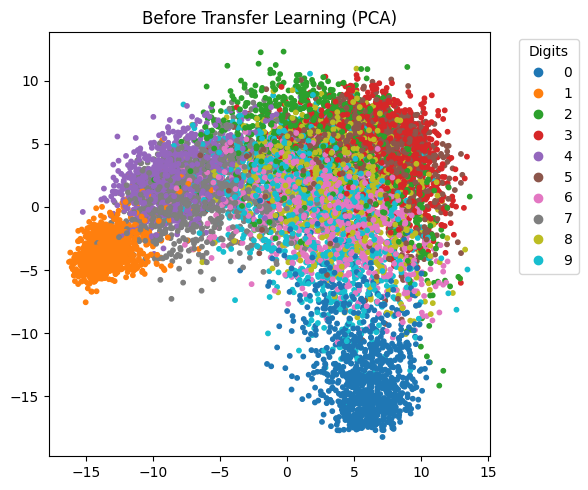

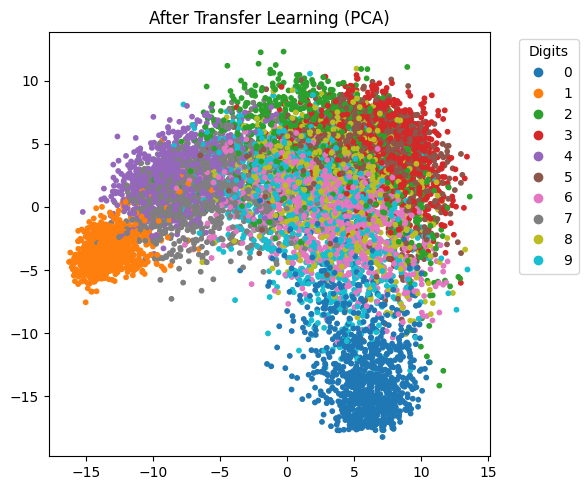

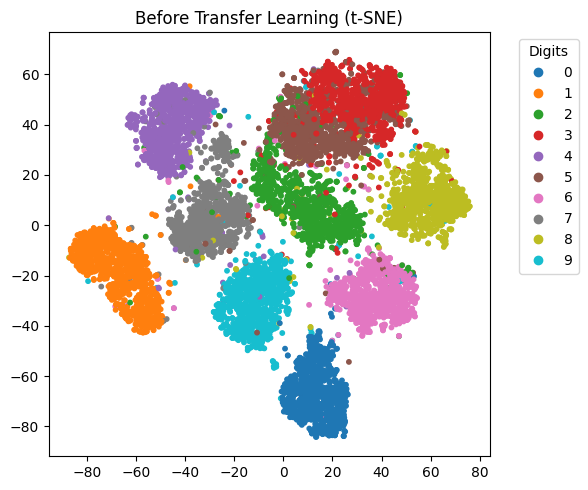

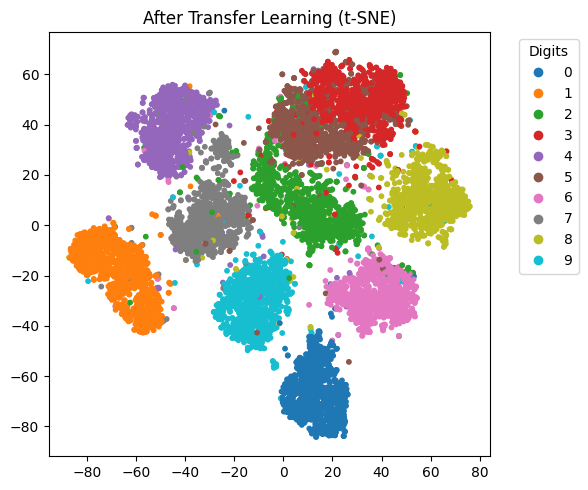

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


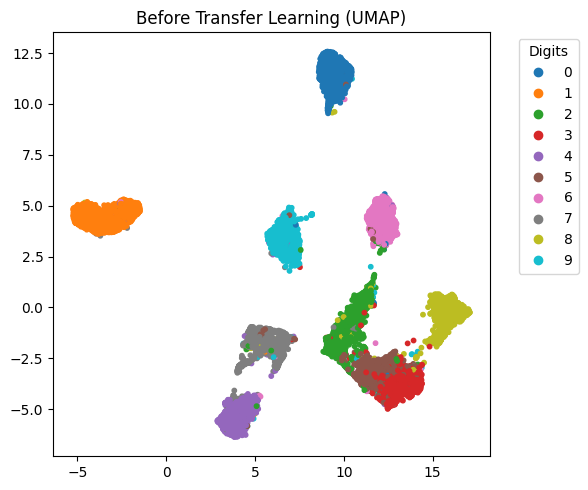

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


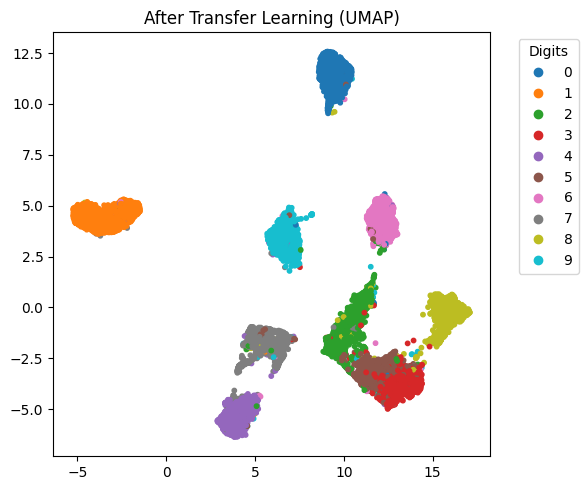

In [15]:

for method in ['PCA', 't-SNE', 'UMAP']:
    plot_2d(features_before, testY, method, f"Before Transfer Learning ({method})")
    plot_2d(features_after, testY, method, f"After Transfer Learning ({method})")
